<a href="https://colab.research.google.com/github/zealand-cs/50-startups/blob/main/50-startups.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mandatory Assignment: Startups

## Domain description

JPM-Finance is an advisory financial company with a small network of rich clients who like to invest in newly started companies (so called startups), before the profit is public.

For each company there are data given by the following features:
*   State
*   R&D Spend
*   Marketing Spend
*   Administration
*   Profit which is the label

Your job is to understand, explore and prepare the data, do a linear regression analysis to be used by JPM-Finance evaluating new startups profit based on the features. The estimate of profit together with a risk analysis of the business segment, will be the foundation for financial advices to clients.

A preliminary interview with the smart boss (nick name JP) and his younger energetic coordinator, Mike, has revealed that:


1.   A few companies have some data set to 0.0, this is for the moment acceptable, meaning you
don’t need to change these numbers into mean values or drop the respective companies.
Some small startups actually don’t have any administration costs!
2.   The 'State' feature is a text attribute, and from previous study not very important, meaning one can drop this feature. Thus, all calculations using `OneHotEncoder` are superfluous. Just skip them for a start. Later if You like, You can play with the `OneHotEncoder`.
3.  If the correlation matrix of the features only has values higher than 0.20 (lower than -0.20), it is a pretty bad idea to try to combine attributes, as this can blur the picture and make
wrong weights to the features




## References

It should not be necessary to find stuff by "Googling" or "ChatGPT'ing" for the purpose of finishing this assigment. Maybe for checking only.  

Try to concentrate on the following references:
*   Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems, Aurélien Géron,
 3rd edition, Ch. 1 & 2.
*   Coding stuff for ch. 1: https://github.com/ageron/handson-ml3/blob/main/01_the_machine_learning_landscape.ipynb
*   Coding stuff for ch. 2: https://github.com/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb
*   Stuff from Moodle room. Especially, "End-to-End Project Model" sections.






## Setting up Python Environment

Installing stuff

This project requires Python 3.7 or above:

In [362]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [363]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Import common libraries used with learning in Python

In [364]:
import pandas as pd
from pathlib import Path

In [365]:
import numpy as np

## Step 1: Look at the big picture and frame the problem

**1. Define the objective in business terms.**

    The objective is to perform a linear regression analysis to estimate the
    profit of new startups based on given features. This profit estimate,
    combined with a risk analysis, will be used by JPM-Finance to provide
    financial advice to its clients regarding investments in startups.

**2. How shall your solution be used? (User stories)**

    JPM-Finance will use the solution to evaluate the potential profit of new
    startups and provide financial advice to its clients on investment
    opportunities.
    
    A user story could be: "As a JPM-Finance advisor, I want to
    accurately predict a startup's profit so I can provide sound investment
    advice to my clients."

**3. What are the current solutions/workarounds (if any)?**

    Nothing is known.

**4. How should you frame this problem (supervised/unsupervised, online/offline, etc.)?**

    This is a supervised learning problem because the target variable (Profit)
    is known. It is a regression task since the goal is to predict a continuous
    numerical value. It will be an offline learning system, as the model will
    be trained on historical data.

**5. How should performance be measured?**

    Since this is a regression problem, common performance measures like Root
    Mean Squared Error (RMSE) or Mean Absolute Error (MAE) would be appropriate.

**6. Is the performance measure aligned with the business objective?**

    Yes, RMSE or MAE directly measure the average magnitude of the errors,
    which is crucial for JPM-Finance to assess the accuracy of their profit
    predictions and subsequently the quality of their financial advice. Lower
    error means more reliable advice.

**7. What would be the minimum performance needed to reach the business objective?**

    N/A, as there is no baseline regarding current performance.

**8. What are comparable problems? Can you reuse experience?**

    This problem is comparable to other regression tasks in finance or
    business, such as predicting housing prices (as in Chapter 2 of the
    reference book) or sales forecasting. Experience and techniques from the
    provided references, especially the end-to-end machine learning project
    described in Chapter 2, can be reused.

**9. Is human expertise available?**

    N/A, as no domain experts are available.

**10. How would you solve the problem manually?**

    N/A, as there is no idea about it.

**11. List the assumptions you (or others have made so far)**

    The following assumptions have been made based on the preliminary interview
    with JP and Mike:
  
    -   Zero values for certain features (e.g., administration costs) are
        acceptable and do not need to be imputed or dropped.
    -   The 'State' feature can be dropped as it is considered not very
        important, making `OneHotEncoder` calculations superfluous for a start.
    -   Attribute combinations should be avoided if the correlation matrix of
        the features only has values with an absolute magnitude less than or
        equal to 0.20, as this can blur the picture and create wrong weights.

**12. Verify assumptions if possible**

    N/A, as there is no time for this.

## Step 2: Get the data

**1. List the data you need and how much you need.**
    
    N/A in this task.

**2. Find and document where you can get that data.**

    N/A in this task because the data set is given.

**3. Check out how much space it requires.**
   
    2.4K which is not noteworthy.

**4. Check legal obligations, and get authorization if necessary.**

    N/A here because no legal matters are involved. Otherwise, GDPR issues,ownerships rights etc. should be considered.

**5. Get access authorizations.**

    Nothing to be done here. Otherwise, this may be a tedious and bureaucratic procedure that has to be considered in the planning.

**6. Create a workspace (with enough storage space).**

    Done with Google Colab and GitHub. There's enough space.

**7. Get the data.**

    Done beneath this section. Hosted in same repository as this notebook.

**8. Convert the data to a format you can easily manipulate (without changing the data itself).**

    The data is in CSV (Comma Seperated Values) which is exactly as described.
    Not much more to do here except for general manipulation with Python.

**9. Ensure sensitive information is deleted or protected (e.g., anonymized).**

    N/A as there is none. Otherwise, legal obligations should always be checked
    as aminimum. Note: Data may also be considered sensitive for other reasons.

**10. Check the size and type of data (time series, sample, geographical, etc.).**
Action: Code is to be established in your notebook like section ‘Take a Quick Look at the Data Structure’ in notebook for chapter 2.
    
    Only 50 data rows are given. Most likely manually entered (ignoring the fact
    that this is an assignment). It is not a time series, a sample or any
    geographical (except for city name) thing. It's mostly about profits and costs,
    so primarily simple numbers. We just opened the file and looked at it, with no coding.

**11. Create a test set, put it aside, and never look at it (no data snooping!).**
A problem here is that the data set is small -> Use stratification.
Action: Make stratified test and learning sets (1 fold).
Code is to be established in your notebook. Find your stuff in section ‘Create a Test Set’ in notebook for chapter 2

    See code below in Getting the data

### Getting the data

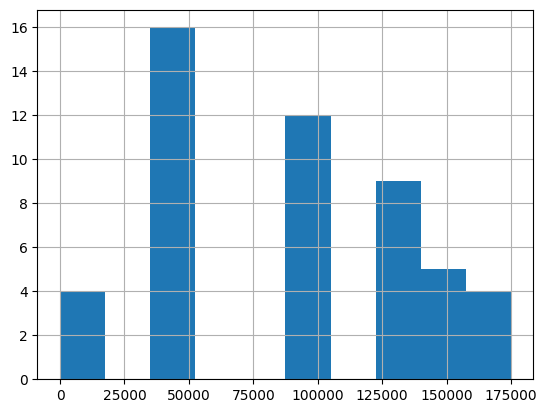

In [366]:
#Importing the dataset
datafile="https://raw.githubusercontent.com/zealand-cs/50-startups/refs/heads/main/data.csv"
dataset = pd.read_csv(datafile)

from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(dataset, test_size=0.2, random_state=42)

dataset["ProfitCat"] = pd.cut(dataset["Profit"],
bins=[0, 50000, 100000, 125000, 150000, 175000, 200000, np.inf],
labels=[0, 50000, 100000, 125000, 150000, 175000, 200000])

dataset["ProfitCat"].hist()

from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(dataset, dataset["ProfitCat"]):
  strat_train_set = dataset.loc[train_index]
  strat_test_set = dataset.loc[test_index]

strat_test_set["ProfitCat"].value_counts() / len(strat_test_set)

for set_ in (strat_train_set, strat_test_set):
  set_.drop("ProfitCat", axis=1, inplace=True)

## Step 3. Explore the data

You are now ready to make a notebook (in Jupyter or Colab) for exploring the data. Remember your experience from the investigation of “Housing” in Chapter 2.

**1. Create a copy of the data for exploration**

    See code below

**2. Create a notebook to keep a record of your data exploration**

    Nothing to be done. This is already a notebook.

**3. Study each attribute and its characteristics**

    See code below

**4. For supervised learning tasks, identify the target attribute(s); i.e. the label(s)**

    "Marketing spend", "R&D Spend" and "Profits" looks promising. That looks delecious.

**5. Discover and visualize the data by scatter plots for each numerical attribute**

    Nothing to be documented

**6. Study the correlations between attributes**

    See code below

**7. Study how you would solve the problem manually**

    Nothing to be documented.

**8. Experiment with attribute combinations**

    See code below

**9. Identify a new promising attribute you may want to apply, if any**

    Looking at the dataset, 'RDPerAdministration' and 'MarketingPerAdministration' looks quite promising

**10. Identify extra data that would be useful (go back to “Get the Data”)**

    N/A as were are limited to ‘50 Start-ups’ dataset
    However, you may document any suggestions for extra data features – e.g. in your notebook.

In [367]:
# 3.1
data_3 = strat_train_set.copy()

In [368]:
# 3.3

display(data_3.head())

,R&D Spend,Administration,Marketing Spend,State,Profit
47,0.00,135426.92,0.00,California,42559.73
14,119943.24,156547.42,256512.92,Florida,132602.65
28,66051.52,182645.56,118148.20,Florida,103282.38
12,93863.75,127320.38,249839.44,Florida,141585.52
13,91992.39,135495.07,252664.93,California,134307.35


In [369]:
# 3.3

data_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40 entries, 47 to 7
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        40 non-null     float64
 1   Administration   40 non-null     float64
 2   Marketing Spend  40 non-null     float64
 3   State            40 non-null     object 
 4   Profit           40 non-null     float64
dtypes: float64(4), object(1)
memory usage: 1.9+ KB


In [370]:
# 3.3

data_3["State"].value_counts()

,count
State,
Florida,15
New York,13
California,12


In [371]:
# 3.3

data_3.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,40.000000,40.000000,40.000000,40.000000
mean,73291.983750,123838.642000,215790.926500,111949.676750
std,45491.946645,25513.335919,121754.304868,39812.154178
min,0.000000,65947.930000,0.000000,14681.400000
25%,44150.142500,105077.645000,130074.602500,95036.680000
50%,69820.065000,125604.625000,221897.880000,106568.940000
75%,100982.240000,144484.500000,298932.675000,136126.892500
max,165349.200000,182645.560000,471784.100000,192261.830000


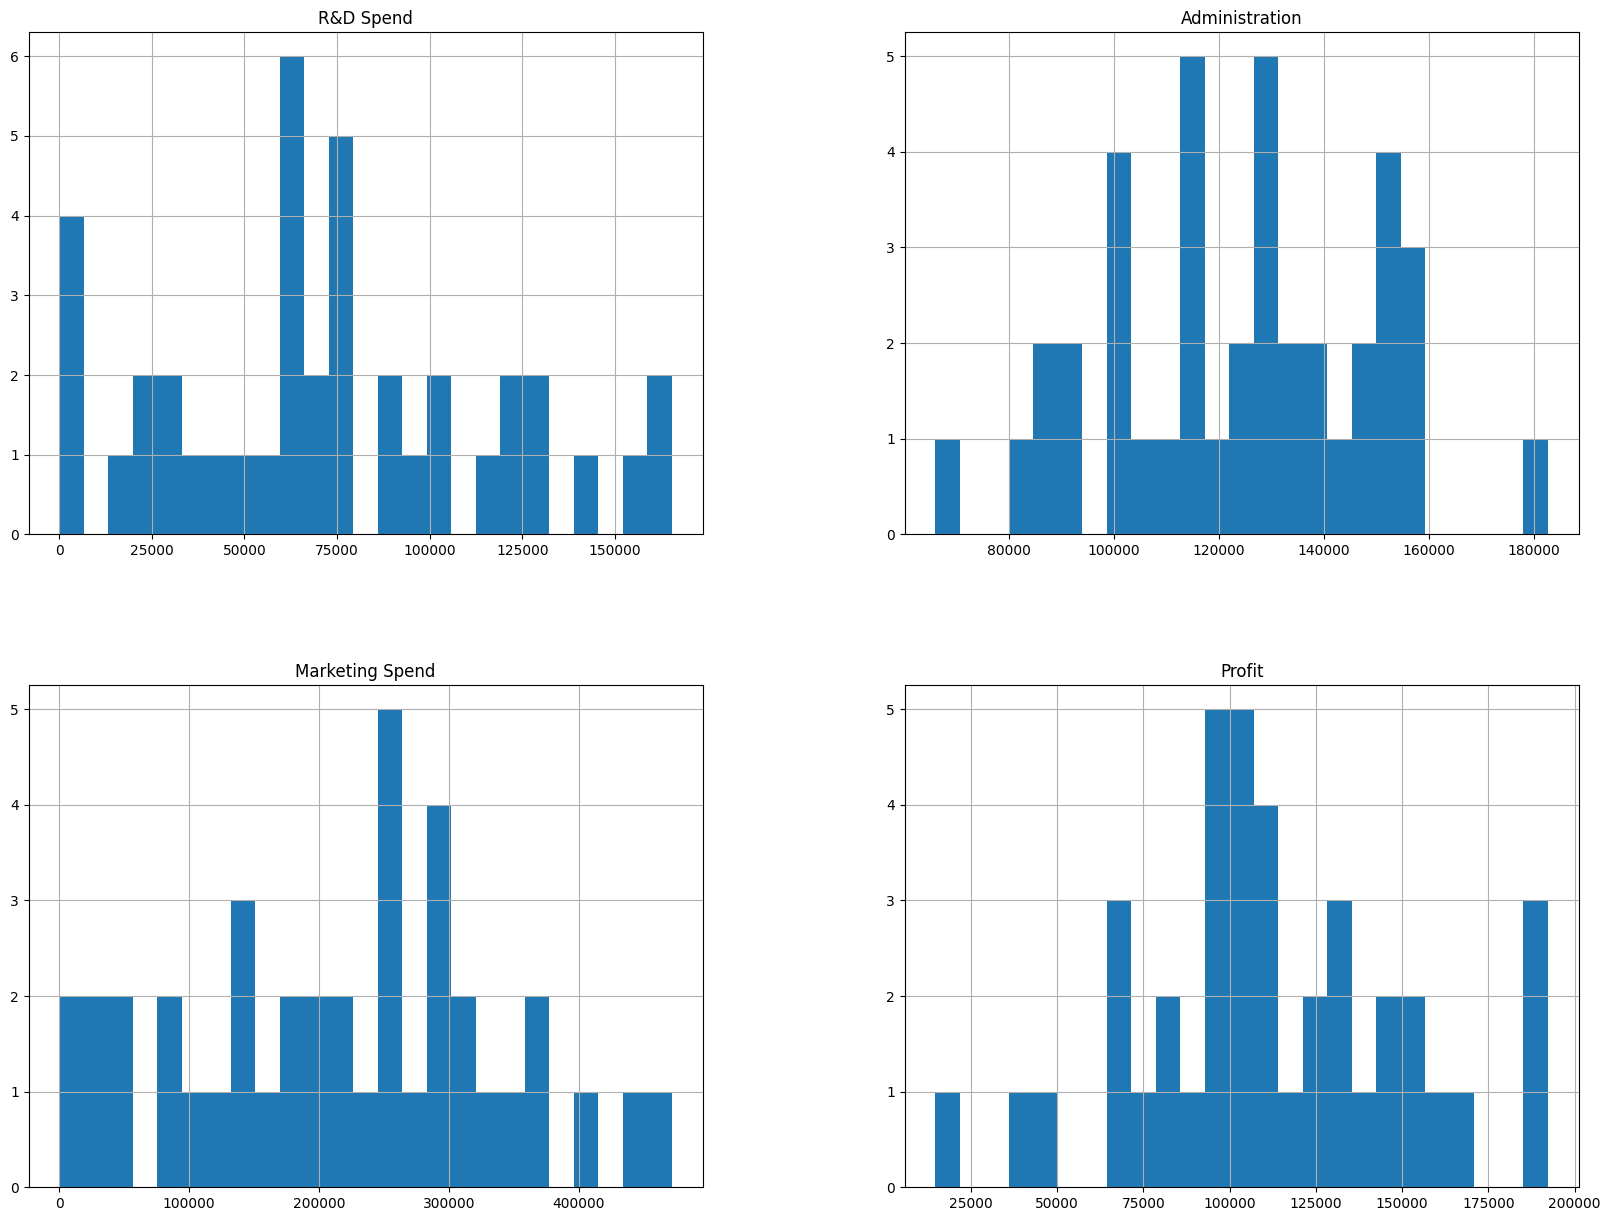

In [372]:
%matplotlib inline
import matplotlib.pyplot as plt
data_3.hist(bins=25, figsize=(20,15))
plt.savefig("attribute_histogram_plots")
plt.show()

array([[<Axes: xlabel='R&D Spend', ylabel='R&D Spend'>,
        <Axes: xlabel='Administration', ylabel='R&D Spend'>,
        <Axes: xlabel='Marketing Spend', ylabel='R&D Spend'>,
        <Axes: xlabel='Profit', ylabel='R&D Spend'>,
        <Axes: xlabel='State', ylabel='R&D Spend'>],
       [<Axes: xlabel='R&D Spend', ylabel='Administration'>,
        <Axes: xlabel='Administration', ylabel='Administration'>,
        <Axes: xlabel='Marketing Spend', ylabel='Administration'>,
        <Axes: xlabel='Profit', ylabel='Administration'>,
        <Axes: xlabel='State', ylabel='Administration'>],
       [<Axes: xlabel='R&D Spend', ylabel='Marketing Spend'>,
        <Axes: xlabel='Administration', ylabel='Marketing Spend'>,
        <Axes: xlabel='Marketing Spend', ylabel='Marketing Spend'>,
        <Axes: xlabel='Profit', ylabel='Marketing Spend'>,
        <Axes: xlabel='State', ylabel='Marketing Spend'>],
       [<Axes: xlabel='R&D Spend', ylabel='Profit'>,
        <Axes: xlabel='Administration

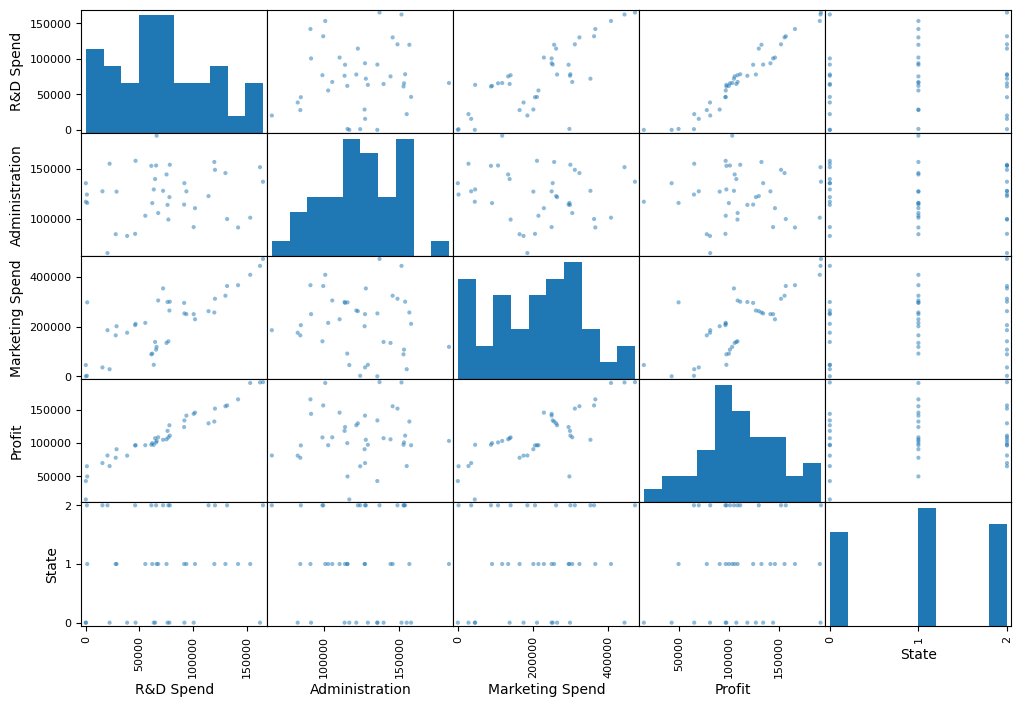

In [373]:
# 3.6
from pandas.plotting import scatter_matrix

data_3['State'] = data_3['State'].astype('category').cat.codes

attributes = ["R&D Spend", "Administration", "Marketing Spend", "Profit", "State"]
scatter_matrix(data_3[attributes], figsize=(12, 8))

,Profit
Profit,1.000000
R&D Spend,0.968764
RDPerAdministration,0.922498
Marketing Spend,0.792110
MarketingPerAdministration,0.686591
State,0.108143
RDPerMarketing,0.103125
Administration,0.050650
AdministrationPerMarketing,-0.257091
MarketingPerRD,-0.322297


array([[<Axes: xlabel='R&D Spend', ylabel='R&D Spend'>,
        <Axes: xlabel='Administration', ylabel='R&D Spend'>,
        <Axes: xlabel='Marketing Spend', ylabel='R&D Spend'>,
        <Axes: xlabel='Profit', ylabel='R&D Spend'>,
        <Axes: xlabel='MarketingPerAdministration', ylabel='R&D Spend'>,
        <Axes: xlabel='RDPerMarketing', ylabel='R&D Spend'>,
        <Axes: xlabel='RDPerAdministration', ylabel='R&D Spend'>],
       [<Axes: xlabel='R&D Spend', ylabel='Administration'>,
        <Axes: xlabel='Administration', ylabel='Administration'>,
        <Axes: xlabel='Marketing Spend', ylabel='Administration'>,
        <Axes: xlabel='Profit', ylabel='Administration'>,
        <Axes: xlabel='MarketingPerAdministration', ylabel='Administration'>,
        <Axes: xlabel='RDPerMarketing', ylabel='Administration'>,
        <Axes: xlabel='RDPerAdministration', ylabel='Administration'>],
       [<Axes: xlabel='R&D Spend', ylabel='Marketing Spend'>,
        <Axes: xlabel='Administration

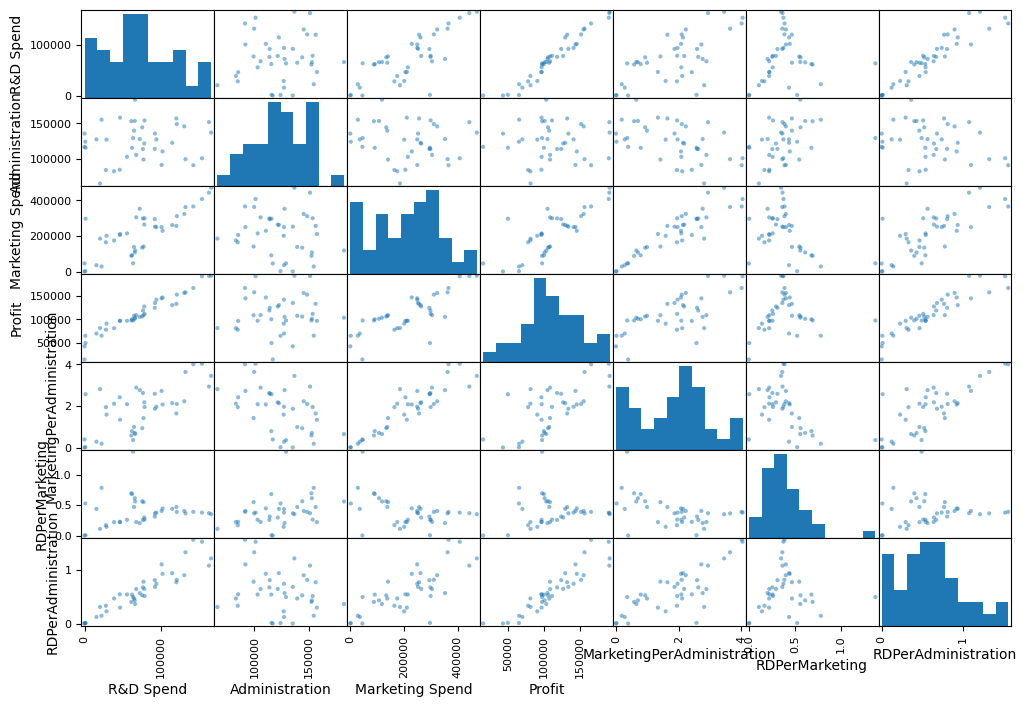

In [374]:
# 3.8

data_3["MarketingPerRD"] = data_3["Marketing Spend"]/data_3["R&D Spend"]
data_3["MarketingPerAdministration"]=data_3["Marketing Spend"]/data_3["Administration"]
data_3["AdministrationPerRD"] = data_3["Administration"]/data_3["R&D Spend"]
data_3["AdministrationPerMarketing"]=data_3["Administration"]/data_3["Marketing Spend"]
data_3["RDPerMarketing"] = data_3["R&D Spend"]/data_3["Marketing Spend"]
data_3["RDPerAdministration"]= data_3["R&D Spend"]/data_3["Administration"]

corr_matrix = data_3.corr()
display(corr_matrix["Profit"].sort_values(ascending=False))

attributes = ["R&D Spend", "Administration", "Marketing Spend", "Profit", "MarketingPerAdministration", "RDPerMarketing", "RDPerAdministration"]
scatter_matrix(data_3[attributes], figsize=(12, 8))

## Step 4. Prepare the data

**Notes:**
*   Work on copies of the data (keep the original dataset intact).
*   Write functions for all data transformations you apply, for five reasons:
1.   So you can easily prepare the data the next time you get a fresh dataset
2.   So you can apply these transformations in future projects
3.   To clean and prepare the test set
4.   To clean and prepare new data instances once your solution is live
5.   To make it easy to treat your preparation choices as hyperparameters

**1. Data cleaning**

    N/A because no values are and no evident outliers detected. Nothing to be
    documented.

**2. Feature selection**

    See code below

**3. Feature engineering, where appropriate**

    To be skipped. Nothing to be documented.

**4. Handle text and categorical attributes using “import OneHotEncoder”**

    See code below

**5. Feature scaling: Standardize or normalize features**

    See code below

In [375]:
# Step 4.2
data_4 = data_3.copy()
# Dropping the features as requested in the task instructions
data_4 = data_4.drop(["AdministrationPerRD", "MarketingPerRD", "AdministrationPerMarketing"], axis=1)
display(data_4.head())

,R&D Spend,Administration,Marketing Spend,State,Profit,MarketingPerAdministration,RDPerMarketing,RDPerAdministration
47,0.00,135426.92,0.00,0,42559.73,0.000000,NaN,0.000000
14,119943.24,156547.42,256512.92,1,132602.65,1.638564,0.467591,0.766178
28,66051.52,182645.56,118148.20,1,103282.38,0.646871,0.559057,0.361638
12,93863.75,127320.38,249839.44,1,141585.52,1.962289,0.375696,0.737225
13,91992.39,135495.07,252664.93,0,134307.35,1.864754,0.364088,0.678935


In [376]:
# Step 4.4 and 4.5
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.linear_model import LinearRegression

# Separate features and labels
data_4_features = data_4.drop("Profit", axis=1)
data_4_labels = data_4["Profit"].copy()

# Define pipelines for numerical and categorical data
num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

# Combine into a ColumnTransformer
# Using make_column_selector to automatically include all new engineered numerical columns
preprocessing = ColumnTransformer([
    ("num", num_pipeline, make_column_selector(dtype_include=np.number)),
    ("cat", cat_pipeline, ["State"]),
])

In [377]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

In [378]:
data_4_prepared = preprocessing.fit_transform(data_4)

In [379]:
preprocessing.get_feature_names_out()

array(['pipeline-1__R&D Spend', 'pipeline-1__Administration',
       'pipeline-1__Marketing Spend', 'pipeline-1__State',
       'pipeline-1__Profit', 'pipeline-1__MarketingPerAdministration',
       'pipeline-1__RDPerMarketing', 'pipeline-1__RDPerAdministration'],
      dtype=object)

## Step 5. Select and train a model

### Evaluating the model on the test set

**Notes:**
*   If the data is huge, you may want to sample smaller training sets so you can train many
different models in a reasonable time (be aware that this penalizes complex models such as
large neural nets or Random Forests).
*   Once again, try to automate these steps as much as possible




**1. Train many quick-and-dirty models from different categories (e.g., linear, naive Bayes, SVM, Random Forest, neural net, etc.) using standard default parameters**

    See code below

**2. Measure and compare the performance**

    See code below

**3. Analyze the most significant variables for each algorithm**

    See code below

**4. Analyze the types of errors the model makes**

    I honestly don't see any errors

**5. Perform a quick round of feature selection and engineering**

    Based on the analasys from before, the "State" is not useful at all. We skip it.


**6. Consider another quick-and-dirty model from different categories (e.g., naive Bayes, SVM,
Random Forest, neural net, etc.)**

    Considered N/A, just go on with the LinearRegression model. Nothing to be
    documented.

**7. Perform one or two more quick iterations of the five previous steps**

    Condidered N/A, just go on with the LinearRegression model. Nothing to be
    documented.

**8. Shortlist the top one to two most promising models, preferring models that make different
types of errors.**

    Considered N/A, just go on with the LinearRegression model. Nothing to be documented

In [380]:
# 5.1
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

# Train using only the features (data_4_features), not the whole dataframe
lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(data_4_features, data_4_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7a689176af90>),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7a6891768f50>)])),
                ('linearregression', LinearRegression())])

In [381]:
data_4_predictions = lin_reg.predict(data_4_features)
display(data_4_predictions[:5])

array([ 45693.18783587, 147069.78504904, 101583.49606241, 127918.43169153,
       126159.23409526])

In [382]:
data_4_labels.iloc[:5].values

array([ 42559.73, 132602.65, 103282.38, 141585.52, 134307.35])

In [383]:
# 5.2
error_ratios = data_4_predictions[:5] / data_4_labels.iloc[:5].values - 1
print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

7.4%, 10.9%, -1.6%, -9.7%, -6.1%


In [384]:
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        return mean_squared_error(labels, predictions, squared=False)

lin_rmse = root_mean_squared_error(data_4_labels[:5], data_4_predictions[:5])
lin_rmse

9748.68049326054

In [387]:
# 5.3

import pandas as pd

correlations = data_4.corr()['Profit'].drop('Profit')

feature_names = lin_reg.named_steps['columntransformer'].get_feature_names_out()
coefficients = lin_reg.named_steps['linearregression'].coef_

display(pd.DataFrame({
    'Model Feature': feature_names,
    'Weight (Coefficient)': coefficients
}).sort_values(by='Weight (Coefficient)', ascending=False))

display(correlations.sort_values(ascending=False))

,Feature,Coefficient
0,pipeline-1__R&D Spend,35040.709037
4,pipeline-1__MarketingPerAdministration,6886.017289
5,pipeline-1__RDPerMarketing,2786.564486
2,pipeline-1__Marketing Spend,387.699126
1,pipeline-1__Administration,-67.685308
3,pipeline-1__State,-112.103759
6,pipeline-1__RDPerAdministration,-2218.364578


In [ ]:
# Step 5.5

data_4 = data_4.drop(["State"], axis=1)


## Step 6: Fine tune and test the model

**Notes:**
*   You will want to use as much data as possible for this step, especially as you move toward the end of fine-tuning.
*   As always, automate what you can


**1. Fine-tune the hyperparameters using cross-validation**

Action: Try grid search on the LinearRegression algorithm. Indentify the relevant (hyper-)
parameters and include in the search. Code is to be established in your notebook that is doing a grid search similar to what is done in section ‘Fine-Tune Your Model’ in notebook for chapter 2. Consider the following:
*  Treat your data transformation choices as hyperparameters, especially when you are not sure about them (e.g., if you’re not sure whether to replace missing values with zeros or with the median value, or to just drop the rows).
*  Unless there are very few hyperparameter values to explore, prefer random search over grid search. If training is very long, you may prefer a Bayesian optimization approach (e.g., using Gaussian process priors, as described by Jasper Snoek et al.).

    // TODO

**2. Try Ensemble methods. Combining your best models will often produce better performance than running them individually.**

    N/A as we are just applying a single model. Nothing to be documented.

**3. Once you are confident about your final model, measure its performance on the test set to estimate the generalization error. This is important!**

Action: Present your model with the set of model parameters that gives the best
performance. Also present the set of hyper parameters that leads to this performance.Code is to be established in your notebook. To be documented – e.g. in your notebook.

    // TODO

**Questions & Tasks**
1. If you have time, consider other models (SVM, Random Forest) and compare the
performance.
2. If you have time, consider “OneHotEncoder” for including the ‘State’ variable into yout
model.


## Step 7. Report and presentation

**1. Document what you have done.Action: Already accomplished with the actions mentioned above.**

    Nothing to be documented.

**2. Create a nice and short introduction**

Make sure you highlight the big picture first.
Action: You may skip this, but so important if you present your model outside your Machine Learning task group.

    // TODO

**3. Explain why your solution achieves the business objective**

Action: To be documented – e.g. in your notebook.

    // TODO

**4. Do not forget to present interesting points you noticed along the way.**

Action: To be documented – e.g. in your notebook., if any.
*  Describe what worked and what did not.
*  List your assumptions and your system’s limitations.

    // TODO

**5. Ensure your key findings are communicated through beautiful visualizations or easy-to-remember statements (e.g., “the median income is the number-one predictor of housing
prices”)**

Action: To be documented – e.g. in your notebook

    // TODO